# CSE 190 Introduction to Deep Learning - Assignment 2
Due at **11:59PM March 13th, 2026**

Put your answers in solution sections, add missing code, run all code blocks.

Make sure you choose a runtime type with a GPU, e.g., T4 GPU. You don't need to subscrible to Colab Pro for such runtime type.

What to submit: Print the notebook with output, save as a PDF, and submit the PDF to CatCourse.

It is very important you include output in the PDF submitted.

Save a copy of this notebook in drive so you don't lose your work.

## Implicit neural field (5 points)

You are supposed to implement and train a multi-layer perceptron for implicit neural filed and train on ONE image only (overfitting).

Related lecture on implicit neural field: lecture 3 on Neural Network

<font color="red">1.  [1 point] </font>Implement a Multi-layer perceptron in pytorch that maps an image coordinate (x,y) to RGB color.



In [1]:
import math
import torch
import torch.nn as nn

class SineLayer(nn.Module):
    def __init__(self, in_features, out_features, bias=True, is_first=False, omega_0=30):
        super().__init__()
        self.in_features = in_features
        self.is_first = is_first
        self.omega_0 = omega_0
        self.linear = nn.Linear(in_features, out_features, bias=bias)
        self.init_weights()

    def init_weights(self):
        with torch.no_grad():
            if self.is_first:
                self.linear.weight.uniform_(-1 / self.in_features, 1 / self.in_features)
            else:
                bound = math.sqrt(6 / self.in_features) / self.omega_0
                self.linear.weight.uniform_(-bound, bound)

    def forward(self, x):
        return torch.sin(self.omega_0 * self.linear(x))


class mlp(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            SineLayer(2, 256, is_first=True, omega_0=30),
            SineLayer(256, 256, omega_0=30),
            SineLayer(256, 256, omega_0=30),
            SineLayer(256, 256, omega_0=30),
            nn.Linear(256, 3),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

<font color="red">2. [3 points]</font> Train the MLP for one image provided at http://www.mengtang.org/yosemite.png , plot loss at each training iteration.

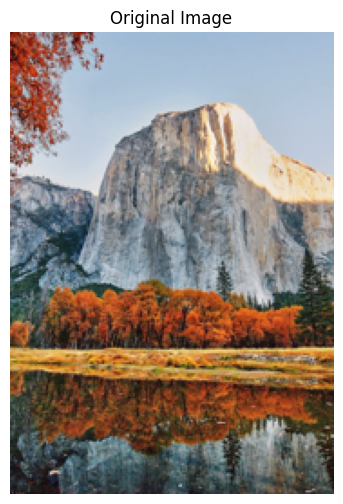

Image shape: torch.Size([3, 256, 179])
Using device: cuda


  0%|          | 0/500 [00:00<?, ?it/s]

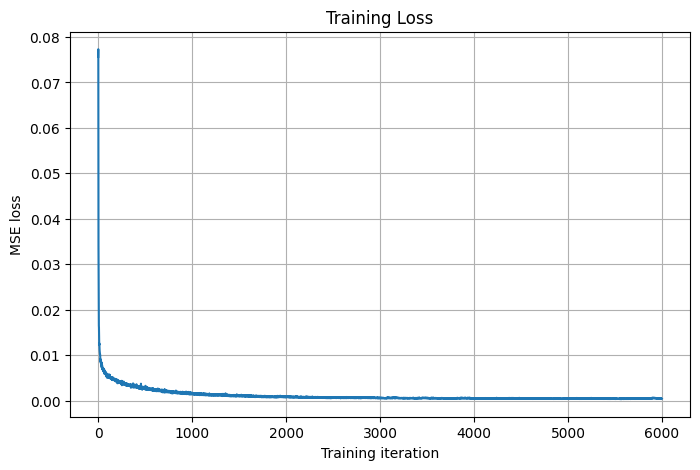

In [2]:
from tqdm.notebook import tqdm
from PIL import Image
import requests
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# -----------------------------
# Download the image
# -----------------------------
url = "http://www.mengtang.org/yosemite.png"
original_image = Image.open(requests.get(url, stream=True).raw).convert("RGB")
original_image.thumbnail((256, 256))   # keep aspect ratio

plt.figure(figsize=(6, 6))
plt.imshow(original_image)
plt.axis("off")
plt.title("Original Image")
plt.show()

# -----------------------------
# Convert image to tensor
# shape: (3, H, W), values in [0,1]
# -----------------------------
transform = transforms.ToTensor()
image_tensor = transform(original_image)

C, H, W = image_tensor.shape
print("Image shape:", image_tensor.shape)

# -----------------------------
# Build training data: (x,y) -> (r,g,b)
# Normalize coordinates to [-1, 1]
# -----------------------------
ys = torch.linspace(-1, 1, H)
xs = torch.linspace(-1, 1, W)
yy, xx = torch.meshgrid(ys, xs, indexing='ij')

coords = torch.stack([xx, yy], dim=-1).reshape(-1, 2)   # (H*W, 2)
rgb = image_tensor.permute(1, 2, 0).reshape(-1, 3)      # (H*W, 3)

dataset = TensorDataset(coords, rgb)
dataloader = DataLoader(dataset, batch_size=4096, shuffle=True)

# -----------------------------
# Model, loss, optimizer
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = mlp().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# -----------------------------
# Train
# -----------------------------
num_epochs = 500
loss_history = []

model.train()
for epoch in tqdm(range(num_epochs)):
    for batch_coords, batch_rgb in dataloader:
        batch_coords = batch_coords.to(device)
        batch_rgb = batch_rgb.to(device)

        pred_rgb = model(batch_coords)
        loss = criterion(pred_rgb, batch_rgb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

# -----------------------------
# Plot loss at each training iteration
# -----------------------------
plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel("Training iteration")
plt.ylabel("MSE loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

<font color="red">3. [1 point]</font> Once the network is trained, predict RGB color at each pixel location, visualize generated image. Also visualize difference between generated image and original image.

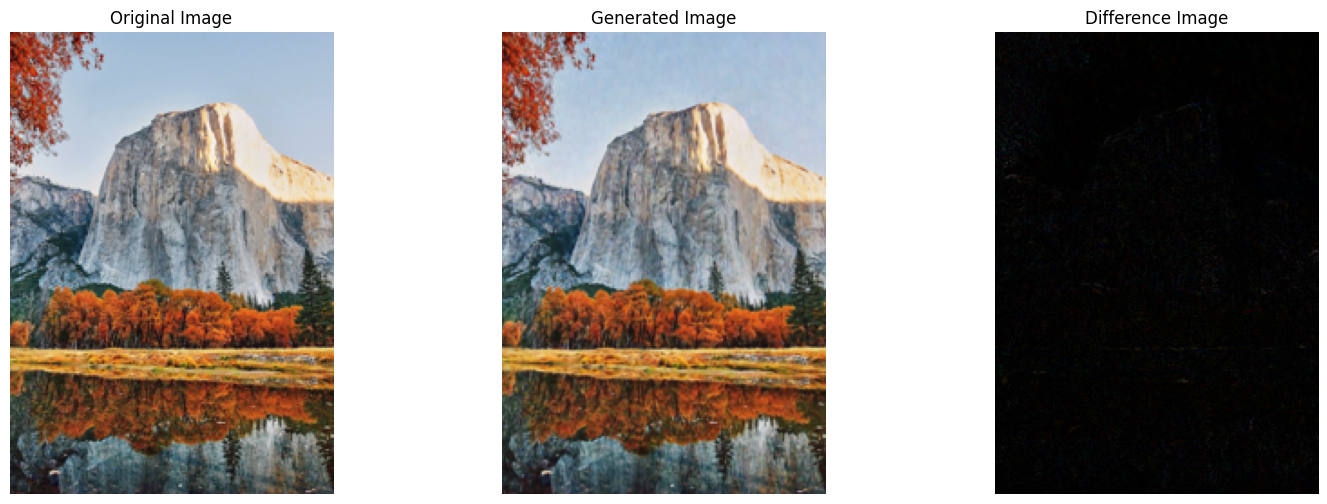

In [3]:
# your code here
# Set model to evaluation mode
model.eval()

# Predict RGB values for every pixel coordinate
with torch.no_grad():
    predicted_rgb = model(coords.to(device)).cpu()   # shape: (H*W, 3)

# Reshape predictions back into image form
generated_image = predicted_rgb.reshape(H, W, 3).numpy()

# Convert original image tensor into H x W x 3 format
original_np = image_tensor.permute(1, 2, 0).numpy()

# Compute absolute difference
difference_image = np.abs(generated_image - original_np)

# Visualize original, generated, and difference images
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(original_np)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(generated_image)
plt.title("Generated Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(difference_image)
plt.title("Difference Image")
plt.axis("off")

plt.show()

<font color="red">4. [Bonus +1 point]</font> A basic implementation of MLP with ReLU activation probably won't give a very accurate reconstructed image. You are encouraged to use SIREN-style network for implicit neural field, which is from the following paper:

Sitzmann, Vincent, et al. "Implicit neural representations with periodic activation functions." Advances in neural information processing systems 2020.

You will get +1 bonus point if your impelmentation is based on SIREN and obtained high-quality reconstruction.